In [18]:
%matplotlib inline

import intake
from access_nri_intake.source.builders import AccessOm2Builder

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
import matplotlib.pyplot as pyplot

from netCDF4 import Dataset

import xesmf as xe

import warnings

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

# figdir = '/g/data/e14/pc5520/figures/basal_melt_param/'
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

In [19]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/40309/status'

### create Basal project part 2 intake:

In [20]:
# add experiments to my own intake:

# - control:
# path_ctrl_s = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW"
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep'


In [21]:
# add SOFIA experiments:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"


In [22]:
# %%time

# builder = AccessOm2Builder(
#     path=path_ctrl
# ).build()

# builder.save(
#     name="21mbath_control", 
#     description="An example datastore for ACCESS-OM2 ryf9091 21mbath control",
# )

In [23]:
# %%time

# builder = AccessOm2Builder(
#     path=path_noBG
# ).build()

# builder.save(
#     name="Basal", 
#     description="Datastore for ACCESS-OM2 ryf9091 Basal",
# )

In [24]:
# %%time

# builder = AccessOm2Builder(
#     path=path_BGB,
#     exclude_patterns ='2delete_output041'
# ).build()

# builder.save(
#     name="Basal_LH_Brine", 
#     description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
# )

In [25]:
# %%time

# builder = AccessOm2Builder(
#     path=path_ctrl_sofia
# ).build()

# builder.save(
#     name="Control_SOFIA", 
#     description="An example datastore for ACCESS-OM2 ryf9091 SOFIA SSP1.2-6",
# )

load my own intake:

In [26]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] # This is important
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable"] # This is important
)

# cat_BG_s = intake.open_esm_datastore(
#     "./Basal_LH.json",
#     columns_with_iterables=["variable"] # This is important
# )

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] # This is important
)

In [27]:
cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

### define slice in time and latitude and load variables:

In [28]:
%%time
# Make sure these match the available restarts:
start_time='1918-01-01'
end_time='1919-12-31'
lat_slice  = slice(-80,-59)


CPU times: user 32 μs, sys: 0 ns, total: 32 μs
Wall time: 61 μs


In [29]:
d1 = cat.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_ctrl = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat.search(variable="river", frequency='1mon').to_dask()
river_ctrl = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_ctrl = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_ctrl = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_ctrl = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_ctrl = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
fprec_ctrl = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d10 = cat.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
lprec_ctrl = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
evap_ctrl = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [30]:
d1 = cat_sofia.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_ctrl_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_sofia.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_ctrl_s = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_sofia.search(variable="river", frequency='1mon').to_dask()
river_ctrl_s = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_sofia.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_ctrl_s = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_sofia.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_ctrl_s = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_sofia.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_ctrl_s = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_sofia.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_ctrl_s = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_sofia.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
fprec_ctrl_s = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d10 = cat_sofia.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
lprec_ctrl_s = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat_sofia.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
evap_ctrl_s = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [31]:
d1 = cat_noBG.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_noBG.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_noBG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_noBG.search(variable="river", frequency='1mon').to_dask()
river_noBG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_noBG.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_noBG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_noBG.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_noBG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_noBG.search(variable="basal_fwflx2d", frequency='1mon',file_id='rregionocean_monthly_2d_basal').to_dask()
basal2d_noBG = d6#sel(time=slice(start_time, end_time)).isel(yt_ocean=lat_slice)
basal2d_noBG = basal2d_noBG.rename({'yt_ocean_sub01':'yt_ocean','xt_ocean_sub01':'xt_ocean'})
# d6b = cat_noBG.search(variable="basal_fwflx", frequency='1mon',file_id='ocean_monthly_3d_basal').to_dask()
# basal3d_noBG = d6b#.sel(time=slice(start_time, end_time)).isel(yt_ocean=lat_slice)

d7 = cat_noBG.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_noBG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_noBG.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_noBG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_noBG.search(variable="icb_fwflx2d", frequency='1mon',file_id='rregionocean_monthly_2d_basal').to_dask()
icb2d_noBG = d9#.sel(time=slice(start_time, end_time)).isel(yt_ocean=lat_slice)
icb2d_noBG = icb2d_noBG.rename({'yt_ocean_sub01':'yt_ocean','xt_ocean_sub01':'xt_ocean'})


#### investigate basal fwflx in basal_noGade expt:

The extension of the basal_noGade (years 10-19) and the 10-yrs basal_noGade_sofia_ssp585 does not have the basal fluxes correctly saved. The configuration is the same except for the diag_table (borrowed from BGB_rep), which was different from what Pedro had before. The comparison of the basal_fwflx (2d) between basal_nogade and BGB show they are very similar. Important to use rregionocean_monthly_2d_basal.nc file_id!! (not saved in the mentioned years/expt).

In [33]:
basal2d_noBG#['basal_fwflx2d'] #### in the northern hemisphere?!?!?

<xarray.Dataset> Size: 883MB
Dimensions:        (time: 120, yt_ocean: 511, xt_ocean: 3600)
Coordinates:
  * time           (time) object 960B 1900-01-16 12:00:00 ... 1909-12-16 12:0...
  * yt_ocean       (yt_ocean) float64 4kB 9.969e+36 9.969e+36 ... -59.03 -58.98
  * xt_ocean       (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.85 79.95
Data variables:
    basal_fwflx2d  (time, yt_ocean, xt_ocean) float32 883MB dask.array<chunksize=(1, 36, 45), meta=np.ndarray>
Attributes: (12/16)
    filename:                                 rregionocean_monthly_2d_basal.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['basal_fwflx2d']
    intake_esm_attrs:filename:                rregionocean_monthly_2d_basal.nc
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['', '', '', '', '', 'water_flu...
    intake_esm_attrs:variable_cell_methods:   ['', '', '', '', 'time: mean', ...
    intake_esm_attrs:variable_units:          ['degrees_E', 'degrees_N', 'day...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   rregionocean_monthly_2d_basal.1mon

In [34]:
basal2d_noBG.yt_ocean.isel(yt_ocean=slice(27,-1)).values # remove first 21 first indices

array([ 9.96920997e+36,  9.96920997e+36,  9.96920997e+36,  9.96920997e+36,
        9.96920997e+36,  9.96920997e+36,  9.96920997e+36,  9.96920997e+36,
        9.96920997e+36, -7.95880149e+01, -7.95457756e+01, -7.95035362e+01,
       -7.94612969e+01, -7.94190575e+01, -7.93768181e+01, -7.93345788e+01,
       -7.92923394e+01, -7.92501001e+01, -7.92078607e+01, -7.91656214e+01,
       -7.91233820e+01, -7.90811427e+01, -7.90389033e+01, -7.89966640e+01,
       -7.89544246e+01, -7.89121853e+01, -7.88699459e+01, -7.88277065e+01,
       -7.87854672e+01, -7.87432278e+01, -7.87009885e+01, -7.86587491e+01,
       -7.86165098e+01, -7.85742704e+01, -7.85320311e+01, -7.84897917e+01,
       -7.84475524e+01, -7.84053130e+01, -7.83630736e+01, -7.83208343e+01,
       -7.82785949e+01, -7.82363556e+01, -7.81941162e+01, -7.81518769e+01,
       -7.81096375e+01, -7.80673982e+01, -7.80251588e+01, -7.79829195e+01,
       -7.79406801e+01, -7.78984407e+01, -7.78562014e+01, -7.78139620e+01,
       -7.77717227e+01, -

In [35]:
basal2d_noBG['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').values

array([2.911078 , 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687, 2.9096687,
       2.9096687, 2.9096687, 2.9096687, 2.9096687, 

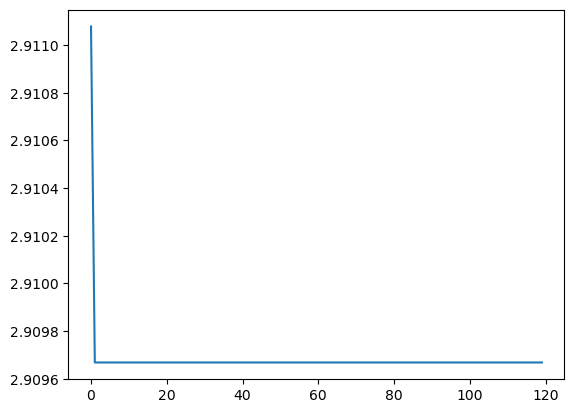

In [36]:
plt.plot(basal2d_noBG['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean'))


In [37]:
basal3d_noBG['basal_fwflx'].max('yt_ocean').max('xt_ocean').max('st_ocean').values

NameError: name 'basal3d_noBG' is not defined

In [ ]:
plt.plot(basal3d_BGB['basal_fwflx'].sum('yt_ocean').sum('xt_ocean').sum('st_ocean'))

In [ ]:
basal2d_BGB['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').values

In [ ]:
plt.plot(basal2d_BGB['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean'))


2025-11-26 19:24:09,754 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/worker.py", line 1267, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/g/d

In [ ]:
# d1 = cat_BG.search(variable="pme_net", frequency='1mon').to_dask()
# pme_net_BG_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d2 = cat_BG.search(variable="pme_river", frequency='1mon').to_dask()
# pme_river_BG_s = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d3 = cat_BG.search(variable="river", frequency='1mon').to_dask()
# river_BG_s = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d4 = cat_BG.search(variable="wfimelt", frequency='1mon').to_dask()
# wfimelt_BG_s = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d5 = cat_BG.search(variable="wfiform", frequency='1mon').to_dask()
# wfiform_BG_s = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d6 = cat_BG.search(variable="basal_fwflx2d", frequency='1mon').to_dask()
# basal2d_BG_s = d6.sel(time=slice(start_time, end_time)).isel(yt_ocean_sub01=slice(27,-1))

# d7 = cat_BG.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
# sfc_salt_flux_ice_BG_s = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d8 = cat_BG.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
# sfc_salt_flux_restore_BG_s = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [ ]:
d1 = cat_BGB.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_BGB = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB.search(variable="river", frequency='1mon').to_dask()
river_BGB = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_BGB = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_BGB = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB.search(variable="basal_fwflx2d", frequency='1mon', file_id='ocean_monthly_2d_basal').to_dask()
basal2d_BGB = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d6b = cat_BGB.search(variable="basal_fwflx", frequency='1mon',file_id='ocean_monthly_3d_basal').to_dask()
basal3d_BGB = d6b.sel(time=slice(start_time, end_time)).isel(yt_ocean=lat_slice)

d7 = cat_BGB.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_BGB = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_BGB = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB.search(variable="briner_fwflx2d", frequency='1mon').to_dask()
brine_BGB = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



In [ ]:
d1 = cat_BGB_sofia.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_BGB_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB_sofia.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_BGB_s = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB_sofia.search(variable="river", frequency='1mon').to_dask()
river_BGB_s = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB_sofia.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_BGB_s = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB_sofia.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_BGB_s = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB_sofia.search(variable="basal_fwflx2d", frequency='1mon').to_dask()
basal2d_BGB_s = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d6b = cat_BGB_sofia.search(variable="basal_fwflx", frequency='1mon',file_id='ocean_monthly_3d_basal').to_dask()
basal3d_BGB_s = d6b.sel(time=slice(start_time, end_time)).isel(yt_ocean=lat_slice)

d7 = cat_BGB_sofia.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_BGB_s = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB_sofia.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_BGB_s = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB_sofia.search(variable="briner_fwflx2d", frequency='1mon').to_dask()
brine_BGB_s = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [ ]:
d1 = cat.search(variable="salt", frequency='1mon').to_dask()
SSS_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_noBG.search(variable="salt", frequency='1mon').to_dask()
SSS_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
# d1 = cat_BG.search(variable="salt", frequency='1mon').to_dask()
# SSS_BG_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_BGB.search(variable="salt", frequency='1mon').to_dask()
SSS_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


In [ ]:
d1 = cat_sofia.search(variable="salt", frequency='1mon').to_dask()
SSS_ctrl_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_noBG_sofia.search(variable="salt", frequency='1mon').to_dask()
SSS_noBG_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_BGB_sofia.search(variable="salt", frequency='1mon').to_dask()
SSS_BGB_s = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


In [ ]:
# convert salt fluxes to FW equivalent:

# A. Kiss don't think we should add this salt fluxes here; we're comparing them but the surface FW budget is given by:
# PME_RIVER = RIVER + MELT (wfiform+wfimelt) + PME (pme_net - (wfiform+wfimelt)) 
FW_restore_ctrl = -(sfc_salt_flux_restore_ctrl.to_dataarray().squeeze()*1000)/SSS_ctrl.isel(st_ocean=0).to_dataarray().squeeze()
# FW_restore_BG = -(sfc_salt_flux_restore_BG.to_dataarray().squeeze()*1000)/SSS_BG.isel(st_ocean=0).to_dataarray().squeeze()
# FW_restore_ICB = -(sfc_salt_flux_restore_ICB.to_dataarray().squeeze()*1000)/SSS_ICB.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_noBG = -(sfc_salt_flux_restore_noBG.to_dataarray().squeeze()*1000)/SSS_noBG.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_BGB = -(sfc_salt_flux_restore_BGB.to_dataarray().squeeze()*1000)/SSS_BGB.isel(st_ocean=0).to_dataarray().squeeze()

# He also says we should use "the fixed bulk salinity of sea ice (ice_salt_concentration = 0.005 kg salt / kg ice), not SSS"
SSSi = 1/0.005

FW_ice_ctrl = -(sfc_salt_flux_ice_ctrl.to_dataarray().squeeze()*1000)/SSSi
# FW_ice_BG = -(sfc_salt_flux_ice_BG.to_dataarray().squeeze()*1000)/SSSi
# FW_ice_ICB = -(sfc_salt_flux_ice_ICB.to_dataarray().squeeze()*1000)/SSSi
FW_ice_noBG = -(sfc_salt_flux_ice_noBG.to_dataarray().squeeze()*1000)/SSSi
FW_ice_BGB = -(sfc_salt_flux_ice_BGB.to_dataarray().squeeze()*1000)/SSSi


In [ ]:
FW_restore_ctrl_s = -(sfc_salt_flux_restore_ctrl_s.to_dataarray().squeeze()*1000)/SSS_ctrl.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_noBG_s = -(sfc_salt_flux_restore_noBG_s.to_dataarray().squeeze()*1000)/SSS_noBG.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_BGB_s = -(sfc_salt_flux_restore_BGB_s.to_dataarray().squeeze()*1000)/SSS_BGB.isel(st_ocean=0).to_dataarray().squeeze()

FW_ice_ctrl_s = -(sfc_salt_flux_ice_ctrl_s.to_dataarray().squeeze()*1000)/SSSi
FW_ice_noBG_s = -(sfc_salt_flux_ice_noBG_s.to_dataarray().squeeze()*1000)/SSSi
FW_ice_BGB_s = -(sfc_salt_flux_ice_BGB_s.to_dataarray().squeeze()*1000)/SSSi


In [ ]:
d1 = cat.search(variable="area_t",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.sel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

In [ ]:
%%time
import numpy.ma as ma

# function to do annual avg and horiz. integral: ONLY SHELF
def var_tavg_hint_shelf(var2d):
    print(var2d.shape)
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# variation of the function for basal variables:
def var_tavg_hint_shelf_basal(var2d):
    print(var2d.shape)
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht.isel(yt_ocean=slice(0,21)) > 1000, var) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t.isel(yt_ocean=slice(0,21)) # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint


# function to test difference b/w horz integral (above) and mean/std:
def var_tavg_havg_std_shelf(var2d): #
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_havg = np.nanmean(np.nanmean(var_masked, axis=1), axis=0) # sum along x/y axis
    var_hstd = np.nanstd(np.nanstd(var_masked, axis=1), axis=0) # sum along x/y axis

    return var_havg, var_hstd


# function to gave integrated on time but no annual average:
def var_hint_shelf(var2d):
    print(var2d.shape)
    # get time length:
    tlen = len(var2d.time)
    for ii in range(0,tlen):
        var_masked = ma.masked_where(ht > 1000, var2d.isel(time=ii)) # masked offshore 1000m isobath
        var_masked_area_tmp = var_masked*area_t # multiply by area
        if ii==0:
             var_hint = np.empty(tlen)
        var_hint_tmp = np.nansum(np.nansum(var_masked_area_tmp, axis=1), axis=0) # sum along x/y axis
        var_hint[ii] = var_hint_tmp
        del var_hint_tmp

    return var_hint

### calculate horiz.-integrated, annual average budget

In [ ]:
%%time
restore_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_salt_flux_restore_ctrl.to_dataarray().squeeze())
restore_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(sfc_salt_flux_restore_ctrl_s.to_dataarray().squeeze())

restore_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_salt_flux_restore_noBG.to_dataarray().squeeze())
restore_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(sfc_salt_flux_restore_noBG_s.to_dataarray().squeeze())

restore_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_salt_flux_restore_BGB.to_dataarray().squeeze())
restore_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(sfc_salt_flux_restore_BGB_s.to_dataarray().squeeze())


In [ ]:
%%time

pme_net_annual_hint_shelf_ctrl = var_tavg_hint_shelf(pme_net_ctrl.to_dataarray().squeeze())
pme_river_annual_hint_shelf_ctrl = var_tavg_hint_shelf(pme_river_ctrl.to_dataarray().squeeze())
river_annual_hint_shelf_ctrl = var_tavg_hint_shelf(river_ctrl.to_dataarray().squeeze())

# melt_annual_hint_shelf_ctrl = var_tavg_hint_shelf(melt_ctrl.to_dataarray().squeeze())
##melt_ctrl_s = wfiform_ctrl + wfimelt_ctrl
wfiform_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfiform_ctrl.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfimelt_ctrl.to_dataarray().squeeze())

FW_restore_annual_hint_shelf_ctrl = var_tavg_hint_shelf(FW_restore_ctrl)
FW_ice_annual_hint_shelf_ctrl = var_tavg_hint_shelf(FW_ice_ctrl)


In [ ]:
%%time

pme_net_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(pme_net_ctrl_s.to_dataarray().squeeze())
pme_river_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(pme_river_ctrl_s.to_dataarray().squeeze())
river_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(river_ctrl_s.to_dataarray().squeeze())

wfiform_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(wfiform_ctrl_s.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(wfimelt_ctrl_s.to_dataarray().squeeze())

FW_restore_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(FW_restore_ctrl_s)
FW_ice_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(FW_ice_ctrl_s)

In [ ]:
# %%time

# pme_net_annual_hint_shelf_BG_s = var_tavg_hint_shelf(pme_net_BG.to_dataarray().squeeze())
# pme_river_annual_hint_shelf_BG_s = var_tavg_hint_shelf(pme_river_BG.to_dataarray().squeeze())
# river_annual_hint_shelf_BG_s = var_tavg_hint_shelf(river_BG.to_dataarray().squeeze())
# wfimelt_annual_hint_shelf_BG_s = var_tavg_hint_shelf(wfimelt_BG.to_dataarray().squeeze())
# wfiform_annual_hint_shelf_BG_s = var_tavg_hint_shelf(wfiform_BG.to_dataarray().squeeze())
# FW_restore_annual_hint_shelf_BG_s = var_tavg_hint_shelf(FW_restore_BG)
# FW_ice_annual_hint_shelf_BG_s = var_tavg_hint_shelf(FW_ice_BG)
# basal_annual_hint_shelf_BG_s = var_tavg_hint_shelf(basal2d_BG.to_dataarray().squeeze())


In [ ]:
# %%time

# pme_net_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_net_ICB.to_dataarray().squeeze())
# pme_river_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_river_ICB.to_dataarray().squeeze())
# river_annual_hint_shelf_ICB = var_tavg_hint_shelf(river_ICB.to_dataarray().squeeze())
# melt_annual_hint_shelf_ICB = var_tavg_hint_shelf(melt_ICB.to_dataarray().squeeze())
# FW_restore_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_restore_ICB)
# FW_ice_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_ice_ICB)

# basal_annual_hint_shelf_ICB = var_tavg_hint_shelf(basal2d_ICB.to_dataarray().squeeze())
# icb_annual_hint_shelf_ICB = var_tavg_hint_shelf(icb2d_ICB.to_dataarray().squeeze())

In [ ]:
%%time

pme_net_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_net_noBG.to_dataarray().squeeze())
pme_river_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_river_noBG.to_dataarray().squeeze())
river_annual_hint_shelf_noBG = var_tavg_hint_shelf(river_noBG.to_dataarray().squeeze())

wfimelt_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfimelt_noBG.to_dataarray().squeeze())
wfiform_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfiform_noBG.to_dataarray().squeeze())
FW_ice_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_ice_noBG)
FW_restore_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_restore_noBG)

basal_annual_hint_shelf_noBG = var_tavg_hint_shelf(basal2d_noBG.isel(yt_ocean=slice(27,-1)).to_dataarray().squeeze())
icb_annual_hint_shelf_noBG = var_tavg_hint_shelf(icb2d_noBG.isel(yt_ocean=slice(27,-1)).to_dataarray().squeeze())


In [ ]:
%%time

pme_net_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(pme_net_noBG_s.to_dataarray().squeeze())
pme_river_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(pme_river_noBG_s.to_dataarray().squeeze())
river_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(river_noBG_s.to_dataarray().squeeze())

wfimelt_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(wfimelt_noBG_s.to_dataarray().squeeze())
wfiform_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(wfiform_noBG_s.to_dataarray().squeeze())
FW_ice_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(FW_ice_noBG_s)
FW_restore_annual_hint_shelf_noBG_s = var_tavg_hint_shelf(FW_restore_noBG_s)

## these were NOT saved!
# basal_annual_hint_shelf_noBG_s = var_tavg_hint_shelf_basal(basal2d_noBG_s.to_dataarray().squeeze())
# icb_annual_hint_shelf_noBG_s = var_tavg_hint_shelf_basal(icb2d_noBG_s.to_dataarray().squeeze())


In [ ]:
%%time

pme_net_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_net_BGB.to_dataarray().squeeze())
pme_river_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_river_BGB.to_dataarray().squeeze())
river_annual_hint_shelf_BGB = var_tavg_hint_shelf(river_BGB.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfimelt_BGB.to_dataarray().squeeze())
wfiform_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfiform_BGB.to_dataarray().squeeze())
FW_restore_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_restore_BGB)
FW_ice_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_ice_BGB)
basal_annual_hint_shelf_BGB = var_tavg_hint_shelf(basal2d_BGB.to_dataarray().squeeze())
brine_annual_hint_shelf_BGB = var_tavg_hint_shelf(brine_BGB.to_dataarray().squeeze())


In [ ]:
%%time

pme_net_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(pme_net_BGB_s.to_dataarray().squeeze())
pme_river_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(pme_river_BGB_s.to_dataarray().squeeze())
river_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(river_BGB_s.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(wfimelt_BGB_s.to_dataarray().squeeze())
wfiform_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(wfiform_BGB_s.to_dataarray().squeeze())
FW_restore_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(FW_restore_BGB_s)
FW_ice_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(FW_ice_BGB_s)
basal_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(basal2d_BGB_s.to_dataarray().squeeze())
brine_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(brine_BGB_s.to_dataarray().squeeze())


In [ ]:
# calculate melt = wfiform + wfimelt

melt_annual_hint_shelf_ctrl = wfiform_annual_hint_shelf_ctrl + wfimelt_annual_hint_shelf_ctrl
melt_annual_hint_shelf_noBG = wfiform_annual_hint_shelf_noBG + wfimelt_annual_hint_shelf_noBG
# melt_annual_hint_shelf_BG = wfiform_annual_hint_shelf_BG + wfimelt_annual_hint_shelf_BG
melt_annual_hint_shelf_BGB = wfiform_annual_hint_shelf_BGB + wfimelt_annual_hint_shelf_BGB
# melt_annual_hint_shelf_ICB = wfiform_annual_hint_shelf_ICB + wfimelt_annual_hint_shelf_ICB


In [ ]:
melt_annual_hint_shelf_ctrl_s = wfiform_annual_hint_shelf_ctrl_s + wfimelt_annual_hint_shelf_ctrl_s
melt_annual_hint_shelf_noBG_s = wfiform_annual_hint_shelf_noBG_s + wfimelt_annual_hint_shelf_noBG_s
melt_annual_hint_shelf_BGB_s = wfiform_annual_hint_shelf_BGB_s + wfimelt_annual_hint_shelf_BGB_s


#### test with avg and std vs integral (horz):

In [ ]:
area_masked = ma.masked_where(ht > 1000, area_t)

In [25]:
area_sum = np.nansum(np.nansum(area_masked, axis=1), axis=0)

(483, 3600)


 ...]

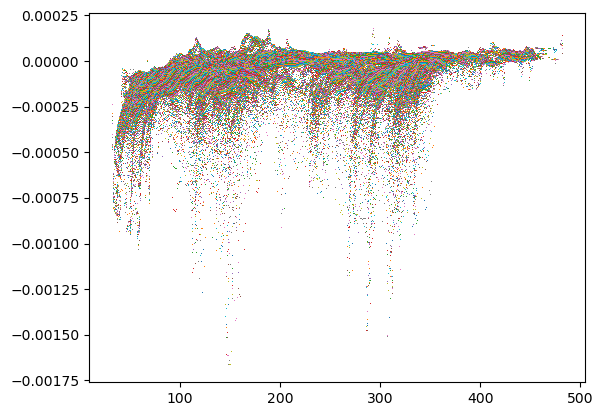

In [26]:
# plot scatter of all values (before averaging):
# pme_net.shape
var = pme_net.mean('time') # annual mean
var_masked = ma.masked_where(ht > 1000, var)

print(var_masked.shape)
plt.plot(var_masked,',')


In [37]:
print(pme_net_annual_hint_shelf_ctrl, pme_net_annual_havg_shelf_ctrl*area_sum, pme_net_annual_hstd_shelf_ctrl*area_sum,
      pme_net_annual_havg_shelf_ctrl, (pme_net_annual_hstd_shelf_ctrl), area_sum)

-195954430.0 -298049800.0 252231970.0 -6.1090854e-05 5.169964e-05 4878795500000.0


In [38]:
print(melt_annual_hint_shelf_ctrl, melt_annual_havg_shelf_ctrl*area_sum, melt_annual_hstd_shelf_ctrl*area_sum,
      melt_annual_havg_shelf_ctrl, (melt_annual_hstd_shelf_ctrl), area_sum)

-196461230.0 -307593400.0 248872900.0 -6.3046995e-05 5.1011135e-05 4878795500000.0


In [39]:
print(pme_river_annual_hint_shelf_ctrl, pme_river_annual_havg_shelf_ctrl*area_sum, pme_river_annual_hstd_shelf_ctrl*area_sum,
      pme_river_annual_havg_shelf_ctrl, (pme_river_annual_hstd_shelf_ctrl), area_sum)

-109564110.0 -124095170.0 1423035500.0 -2.5435616e-05 0.00029167763 4878795500000.0


In [40]:
print(pme_river_annual_hint_shelf_ctrl, pme_river_annual_havg_shelf_ctrl*area_sum, pme_river_annual_hstd_shelf_ctrl*area_sum,
      pme_river_annual_havg_shelf_ctrl, (pme_river_annual_hstd_shelf_ctrl), area_sum)

-109564110.0 -124095170.0 1423035500.0 -2.5435616e-05 0.00029167763 4878795500000.0


NameError: name 'wfiform_annual_havg_shelf_ctrl' is not defined

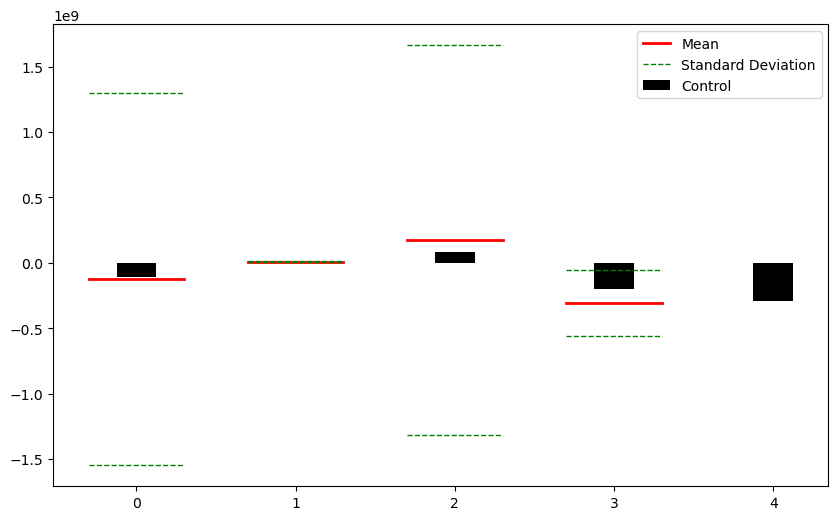

In [41]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))
# pme_river = pme_net + river
pyplot.bar(0, pme_river_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = pme_river_annual_havg_shelf_ctrl*area_sum
std = (+pme_river_annual_hstd_shelf_ctrl)*area_sum
ax.plot([-.3,.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([-.3,.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([-.3,.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)
plt.legend()

# pme_net - melt
pyplot.bar(1, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = (pme_net_annual_havg_shelf_ctrl-melt_annual_havg_shelf_ctrl)*area_sum
std = (+pme_net_annual_hstd_shelf_ctrl-melt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([0.7,1.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([0.7,1.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([0.7,1.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# river
pyplot.bar(2, river_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = river_annual_havg_shelf_ctrl*area_sum
std = (+river_annual_hstd_shelf_ctrl)*area_sum
ax.plot([1.7,2.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([1.7,2.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([1.7,2.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# melt
pyplot.bar(3, melt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = melt_annual_havg_shelf_ctrl*area_sum
std = (+melt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([2.7,3.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([2.7,3.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([2.7,3.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# wfiform
pyplot.bar(4, wfiform_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = wfiform_annual_havg_shelf_ctrl*area_sum
std = (+wfiform_annual_hstd_shelf_ctrl)*area_sum
ax.plot([3.7,4.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([3.7,4.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([3.7,4.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# wfimelt
pyplot.bar(5, wfimelt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = wfimelt_annual_havg_shelf_ctrl*area_sum
std = (+wfimelt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([4.7,5.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([4.7,5.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([4.7,5.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# FW_restore
pyplot.bar(6, FW_restore_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = FW_restore_annual_havg_shelf_ctrl*area_sum
std = (+FW_restore_annual_hstd_shelf_ctrl)*area_sum
ax.plot([5.7,6.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([5.7,6.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([5.7,6.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# ax.set_xticks(np.arange(0,8),('pme_river \n (net FWF)','pme_net \n - melt','river \n river+basal2d \n river+basal2d+icb','melt',
#                               'FW_ice','FW_restore','basal2d (Basal) \n basal2d+icb2d (ICB)','river \n (Basal/ICB)'),rotation=45)

ax.set_xticks(np.arange(0,8),('pme_river \n (net FWF)','pme_net \n - melt','river','melt','wfiform','wfimelt','FW_restore'),rotation=45)
ax.set_xlabel('SFWF components',fontsize=16)
ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=16)

plt.title('Freshwater budget south of 1500m')

### Save fig
# plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr10.png')


In [ ]:
#### 

In [54]:
%%time

pme_net_annual_hint_shelf_BG_s = var_tavg_hint_shelf(pme_net_BG)
pme_river_annual_hint_shelf_BG_s = var_tavg_hint_shelf(pme_river_BG)
river_annual_hint_shelf_BG_s = var_tavg_hint_shelf(river_BG)
melt_annual_hint_shelf_BG_s = var_tavg_hint_shelf(melt_BG)
FW_restore_annual_hint_shelf_BG_s = var_tavg_hint_shelf(FW_restore_BG)
FW_ice_annual_hint_shelf_BG_s = var_tavg_hint_shelf(FW_ice_BG)
basal_annual_hint_shelf_BG_s = var_tavg_hint_shelf(basal2d_BG)


CPU times: user 2min 13s, sys: 5.17 s, total: 2min 18s
Wall time: 2min 21s


In [55]:
%%time

pme_net_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_net_ICB)
pme_river_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_river_ICB)
river_annual_hint_shelf_ICB = var_tavg_hint_shelf(river_ICB)
melt_annual_hint_shelf_ICB = var_tavg_hint_shelf(melt_ICB)
FW_restore_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_restore_ICB)
FW_ice_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_ice_ICB)

basal_annual_hint_shelf_ICB = var_tavg_hint_shelf(basal2d_ICB)
icb_annual_hint_shelf_ICB = var_tavg_hint_shelf(icb2d_ICB)

CPU times: user 3min 55s, sys: 8.98 s, total: 4min 4s
Wall time: 4min 7s


In [62]:
%%time

pme_net_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_net_noBG)
pme_river_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_river_noBG)
river_annual_hint_shelf_noBG = var_tavg_hint_shelf(river_noBG)
basal_annual_hint_shelf_noBG = var_tavg_hint_shelf(basal2d_noBG)
icb_annual_hint_shelf_noBG = var_tavg_hint_shelf(icb2d_noBG)
melt_annual_hint_shelf_noBG = var_tavg_hint_shelf(melt_noBG)
FW_ice_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_ice_noBG)
FW_restore_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_restore_noBG)


CPU times: user 3min 27s, sys: 7.6 s, total: 3min 35s
Wall time: 3min 38s


In [63]:
%%time

pme_net_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(pme_net_BGB)
pme_river_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(pme_river_BGB)
river_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(river_BGB)
melt_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(melt_BGB)
FW_restore_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(FW_restore_BGB)
FW_ice_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(FW_ice_BGB)
basal_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(basal2d_BGB)
brine_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(brine_BGB)


CPU times: user 15.6 s, sys: 979 ms, total: 16.6 s
Wall time: 18.1 s


In [58]:
%%time
## do also for melt components: wfiform/wfimelt

wfimelt_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(wfimelt)
wfiform_annual_hint_shelf_ctrl_s = var_tavg_hint_shelf(wfiform)
wfimelt_annual_hint_shelf_BG_s = var_tavg_hint_shelf(wfimelt_BG)
wfiform_annual_hint_shelf_BG_s = var_tavg_hint_shelf(wfiform_BG)
wfimelt_annual_hint_shelf_ICB = var_tavg_hint_shelf(wfimelt_ICB)
wfiform_annual_hint_shelf_ICB = var_tavg_hint_shelf(wfiform_ICB)
wfimelt_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfimelt_noBG)
wfiform_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfiform_noBG)
wfimelt_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(wfimelt_BGB)
wfiform_annual_hint_shelf_BGB_s = var_tavg_hint_shelf(wfiform_BGB)


CPU times: user 7.39 s, sys: 624 ms, total: 8.02 s
Wall time: 10.7 s


### final plots (annual avg):

In [ ]:
# print values for a table:

print(' --- NET ---')
print('Control = ', pme_river_annual_hint_shelf_ctrl*1e-8)
print('Control SOFIA = ', pme_river_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', pme_river_annual_hint_shelf_noBG*1e-8)
print('noBG SOFIA= ', pme_river_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', pme_river_annual_hint_shelf_BGB*1e-8)
print('BGB SOFIA = ', pme_river_annual_hint_shelf_BGB_s*1e-8)

print(' --- PME ---')
print('Control = ', (pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl)*1e-8)
print('Control  SOFIA= ', (pme_net_annual_hint_shelf_ctrl_s - melt_annual_hint_shelf_ctrl_s)*1e-8)
print('noBG = ', (pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG)*1e-8)
print('noBG  SOFIA= ', (pme_net_annual_hint_shelf_noBG_s - melt_annual_hint_shelf_noBG_s)*1e-8)
print('BGB = ', (pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB)*1e-8)
print('BGB  SOFIA= ', (pme_net_annual_hint_shelf_BGB_s - melt_annual_hint_shelf_BGB_s)*1e-8)

print(' --- RUNOFF (TOTAL) ---')
print('Control = ', river_annual_hint_shelf_ctrl*1e-8)
print('Control  SOFIA= ', river_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', (river_annual_hint_shelf_noBG + basal_annual_hint_shelf_BGB)*1e-8)
print('noBG  SOFIA= ', (river_annual_hint_shelf_noBG_s + basal_annual_hint_shelf_BGB_s)*1e-8)
print('BGB = ', (river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB +  brine_annual_hint_shelf_BGB)*1e-8)
print('BGB  SOFIA= ', (river_annual_hint_shelf_BGB_s + basal_annual_hint_shelf_BGB_s +  brine_annual_hint_shelf_BGB_s)*1e-8)
print(' --- RUNOFF basal/icb only ---')
print('noBG = ', (basal_annual_hint_shelf_BGB)*1e-8)
print('noBG  SOFIA= ', (basal_annual_hint_shelf_BGB_s)*1e-8)
print('BGb = ', (basal_annual_hint_shelf_BGB+brine_annual_hint_shelf_BGB)*1e-8)
print('BGb  SOFIA= ', (basal_annual_hint_shelf_BGB_s+brine_annual_hint_shelf_BGB_s)*1e-8)

print(' --- SEA-ICE ---')
print('Control = ', melt_annual_hint_shelf_ctrl*1e-8)
print('Control  SOFIA= ', melt_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', melt_annual_hint_shelf_noBG*1e-8)
print('noBG  SOFIA= ', melt_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', melt_annual_hint_shelf_BGB*1e-8)
print('BGB  SOFIA= ', melt_annual_hint_shelf_BGB_s*1e-8)

print(' --- SEA-ICE FORM. ---')
print('Control = ', wfiform_annual_hint_shelf_ctrl*1e-8)
print('Control SOFIA= ', wfiform_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', wfiform_annual_hint_shelf_noBG*1e-8)
print('noBG SOFIA= ', wfiform_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', wfiform_annual_hint_shelf_BGB*1e-8)
print('BGB SOFIA = ', wfiform_annual_hint_shelf_BGB_s*1e-8)

print(' --- SEA-ICE MELT ---')
print('Control = ', wfimelt_annual_hint_shelf_ctrl*1e-8)
print('Control SOFIA= ', wfimelt_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', wfimelt_annual_hint_shelf_noBG*1e-8)
print('noBG SOFIA= ', wfimelt_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', wfimelt_annual_hint_shelf_BGB*1e-8)
print('BGB SOFIA= ', wfimelt_annual_hint_shelf_BGB_s*1e-8)

print(' --- FWF SEA-ICE ---')
print('Control = ', FW_ice_annual_hint_shelf_ctrl*1e-8)
print('Control SOFIA= ', FW_ice_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', FW_ice_annual_hint_shelf_noBG*1e-8)
print('noBG SOFIA= ', FW_ice_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', FW_ice_annual_hint_shelf_BGB*1e-8)
print('BGB SOFIA= ', FW_ice_annual_hint_shelf_BGB_s*1e-8)

print(' --- FWF RESTORE ---')
print('Control = ', FW_restore_annual_hint_shelf_ctrl*1e-8)
print('Control SOFIA= ', FW_restore_annual_hint_shelf_ctrl_s*1e-8)
print('noBG = ', FW_restore_annual_hint_shelf_noBG*1e-8)
print('noBG SOFIA= ', FW_restore_annual_hint_shelf_noBG_s*1e-8)
print('BGB = ', FW_restore_annual_hint_shelf_BGB*1e-8)
print('BGBSOFIA = ', FW_restore_annual_hint_shelf_BGB_s*1e-8)

print(' --- basal ---')
print('noBG = ', basal_annual_hint_shelf_BGB*1e-8)
print('noBG SOFIA= ', basal_annual_hint_shelf_BGB_s*1e-8)
print('BGB = ', basal_annual_hint_shelf_BGB*1e-8)
print('BGBSOFIA = ', basal_annual_hint_shelf_BGB_s*1e-8)


#### Shelf-integrated plots - all terms FWF budget:

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (6,6))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.2,  pme_river_annual_hint_shelf_ctrl, width=0.2, color='k', label='Control')
pyplot.bar(0.2, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue', label='BasalGadeBrine')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_BGB, width=0.2, color='#DDAA33', label='Basal')

# plt.legend(fontsize=20)

# test with pme_net - melt
pyplot.bar(0.8, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(1.2, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

pyplot.bar(1.8, river_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(2.2, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_BGB, width=0.2, color='#DDAA33')

# pme_net includes melt!
pyplot.bar(2.8, melt_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(3.2, melt_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(3., melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

pyplot.bar(3.8, wfiform_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(4.2, wfiform_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(4., wfiform_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

pyplot.bar(4.8, wfimelt_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(5.2, wfimelt_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(5., wfimelt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

pyplot.bar(5.8, FW_restore_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(6.2, FW_restore_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(6., FW_restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# pyplot.bar(7.4, brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')

ax.set_xticks(np.arange(0,7),('Net FWF','PME','Runoff','SI net \n = ','(SI form. \n +','SI melt)',
                              'SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=20)
ax.set_ylim(-3.5e8,3.5e8)
ax.yaxis.grid(True, linestyle=':')

ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=20)


plt.title('Surface freshwater budget \n integrated over the continental shelf',fontsize=20)

### Save fig
plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr17-20.png',bbox_inches='tight',dpi=300)


In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (6,6))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.2,  pme_river_annual_hint_shelf_ctrl, width=0.1, color='k', label='Control')
pyplot.bar(-.1,  pme_river_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray', label='Control SOFIA')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_BGB, width=0.1, color='#DDAA33', label='Basal')
pyplot.bar(0.1, pme_river_annual_hint_shelf_noBG_s+ basal_annual_hint_shelf_BGB_s, width=0.1, color='orange', label='Basal SOFIA')
pyplot.bar(0.2, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.1, color='steelblue', label='Basal_LH_Brine')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB_s+(basal_annual_hint_shelf_BGB_s)+ brine_annual_hint_shelf_BGB_s, width=0.1, color='blue', label='Basal_LH_Brine SOFIA')

plt.legend(fontsize=12)

# test with pme_net - melt
pyplot.bar(0.8, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(0.9, pme_net_annual_hint_shelf_ctrl_s - melt_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(1.1, pme_net_annual_hint_shelf_noBG_s - melt_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(1.2, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB_s - melt_annual_hint_shelf_BGB_s+ brine_annual_hint_shelf_BGB_s, width=0.1, color='blue')

pyplot.bar(1.8, river_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(1.9, river_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_BGB, width=0.1, color='#DDAA33') # use basal_BGB
pyplot.bar(2.1, river_annual_hint_shelf_noBG_s + basal_annual_hint_shelf_BGB_s, width=0.1, color='orange') # use basal_BGB_s
pyplot.bar(2.2, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(2.3, river_annual_hint_shelf_BGB_s + basal_annual_hint_shelf_BGB_s, width=0.1, color='blue')

# pme_net includes melt!
pyplot.bar(2.8, melt_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(2.9, melt_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(3., melt_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(3.1, melt_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(3.2, melt_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(3.3, melt_annual_hint_shelf_BGB_s, width=0.1, color='blue')

pyplot.bar(3.8, wfiform_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(3.9, wfiform_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(4., wfiform_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(4.1, wfiform_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(4.2, wfiform_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(4.3, wfiform_annual_hint_shelf_BGB_s, width=0.1, color='blue')

pyplot.bar(4.8, wfimelt_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(4.9, wfimelt_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(5., wfimelt_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(5.1, wfimelt_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(5.2, wfimelt_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(5.3, wfimelt_annual_hint_shelf_BGB_s, width=0.1, color='blue')

pyplot.bar(5.8, FW_restore_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(5.9, FW_restore_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(6., FW_restore_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(6.1, FW_restore_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(6.2, FW_restore_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(6.3, FW_restore_annual_hint_shelf_BGB_s, width=0.1, color='blue')

# pyplot.bar(7.4, brine_annual_hint_shelf_BGB, width=0.1, color='steelblue')

ax.set_xticks(np.arange(0,7),('Net FWF','PME','Runoff','SI net \n = ','(SI form. \n +','SI melt)',
                              'SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=20)
ax.set_ylim(-3.65e8,3.65e8)
ax.yaxis.grid(True, linestyle=':')

ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=20)


plt.title('Surface freshwater budget \n integrated over the continental shelf',fontsize=20)

### Save fig
plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr17-20_ctrlxSOFIA.png',bbox_inches='tight',dpi=300)


In [ ]:
print(figdir+'SFWF_components_annual_hint_shelf_yr17-20_ctrlxSOFIA.png')

#### close look at individual terms:

In [ ]:
fig, ax  = plt.subplots(figsize = (6,6))

pyplot.bar(0.8, FW_restore_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(1.2, FW_restore_annual_hint_shelf_BGB, width=0.2, color='steelblue')
pyplot.bar(1., FW_restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# ax.set_xticks(np.arange(0,1),('SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=12)
# ax.set_ylim(-0.5e8,0.5e8)
# ax.yaxis.grid(True, linestyle=':')

# ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=12)

plt.title('Surface (FW-equiv.) SSS restoring salt flux \n integrated over the continental shelf',fontsize=12)


In [ ]:
fig, ax  = plt.subplots(figsize = (6,6))

pyplot.bar(0.8, restore_annual_hint_shelf_ctrl, width=0.2, color='k', label='control')
pyplot.bar(1, restore_annual_hint_shelf_ctrl_s, width=0.2, color='gray', label='control SOFIA')
pyplot.bar(1.2, restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33', label='Basal')
pyplot.bar(1.4, restore_annual_hint_shelf_noBG_s, width=0.2, color='orange', label='Basal SOFIA')
pyplot.bar(1.6, restore_annual_hint_shelf_BGB, width=0.2, color='steelblue', label='Basal_LH_Brine')
pyplot.bar(1.8, restore_annual_hint_shelf_BGB_s, width=0.2, color='blue', label='Basal_LH_Brine SOFIA')

plt.legend()
ax.set_ylabel('Salt flux (kg/(m^2*sec))',fontsize=12)

ax.yaxis.grid(True, linestyle=':')


# plt.title('Surface salt restoring flux \n integrated over the continental shelf',fontsize=20)
# plt.savefig(figdir+'SSSrestoring_shelfBudge_ctrlxSOFIA_yr18-20.png',bbox_inches='tight',dpi=300)


In [ ]:
## compare Runoff vs SSS restoring:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (6,6))

pyplot.bar(1.8, river_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(1.9, river_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_BGB, width=0.1, color='#DDAA33') # use basal_BGB
pyplot.bar(2.1, river_annual_hint_shelf_noBG_s + basal_annual_hint_shelf_BGB_s, width=0.1, color='orange') # use basal_BGB_s
pyplot.bar(2.2, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(2.3, river_annual_hint_shelf_BGB_s + basal_annual_hint_shelf_BGB_s, width=0.1, color='blue')

pyplot.bar(2.8, FW_restore_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(2.9, FW_restore_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(3., FW_restore_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(3.1, FW_restore_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(3.2, FW_restore_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(3.3, FW_restore_annual_hint_shelf_BGB_s, width=0.1, color='blue')

# pyplot.bar(3.8, river_annual_hint_shelf_ctrl+FW_restore_annual_hint_shelf_ctrl, width=0.1, color='k')
# pyplot.bar(3.9, river_annual_hint_shelf_ctrl_s+FW_restore_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(4., (basal_annual_hint_shelf_BGB), width=0.1, color='#DDAA33')
pyplot.bar(4.1, ( basal_annual_hint_shelf_noBG_s), width=0.1, color='orange')
pyplot.bar(4.2, ( basal_annual_hint_shelf_BGB), width=0.1, color='steelblue')
pyplot.bar(4.3, ( basal_annual_hint_shelf_BGB_s), width=0.1, color='blue')

pyplot.bar(4.8, river_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(4.9, river_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(5., (river_annual_hint_shelf_noBG), width=0.1, color='#DDAA33')
pyplot.bar(5.1, (river_annual_hint_shelf_noBG_s), width=0.1, color='orange')
pyplot.bar(5.2, (river_annual_hint_shelf_BGB ), width=0.1, color='steelblue')
pyplot.bar(5.3, (river_annual_hint_shelf_BGB_s ), width=0.1, color='blue')

pyplot.bar(5.8, river_annual_hint_shelf_ctrl+FW_restore_annual_hint_shelf_ctrl, width=0.1, color='k')
pyplot.bar(5.9, river_annual_hint_shelf_ctrl_s+FW_restore_annual_hint_shelf_ctrl_s, width=0.1, color='darkgray')
pyplot.bar(6., (river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG)+FW_restore_annual_hint_shelf_noBG, width=0.1, color='#DDAA33')
pyplot.bar(6.1, (river_annual_hint_shelf_noBG_s + basal_annual_hint_shelf_noBG_s)+FW_restore_annual_hint_shelf_noBG_s, width=0.1, color='orange')
pyplot.bar(6.2, (river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB)+FW_restore_annual_hint_shelf_BGB, width=0.1, color='steelblue')
pyplot.bar(6.3, (river_annual_hint_shelf_BGB_s + basal_annual_hint_shelf_BGB_s)+FW_restore_annual_hint_shelf_BGB_s, width=0.1, color='blue')


ax.set_xticks(np.arange(1,7),('','Runoff \n (river+basal)',
                              'SSS rest.','basal','river','SUM \n (Runoff+ \n SSSrest)'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=20)
ax.set_ylim(-1.1e8,1.1e8)
# ax.set_xlim(1.5,4.5)
ax.yaxis.grid(True, linestyle=':')

# ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=20)

plt.title('Surface freshwater budget \n integrated over the continental shelf',fontsize=20)

### Save fig
# plt.savefig(figdir+'SFWF_RunoffXSSSrestore_annual_hint_shelf_yr18-20_ctrlxSOFIA.png',bbox_inches='tight',dpi=300)


In [ ]:
### print values of the differences:

print((river_annual_hint_shelf_ctrl+FW_restore_annual_hint_shelf_ctrl)*1e-8)
print((river_annual_hint_shelf_ctrl_s+FW_restore_annual_hint_shelf_ctrl_s)*1e-8)
print(((river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG)+FW_restore_annual_hint_shelf_noBG)*1e-8)
print(((river_annual_hint_shelf_noBG_s + basal_annual_hint_shelf_noBG_s)+FW_restore_annual_hint_shelf_noBG_s)*1e-8)
print(((river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB)+FW_restore_annual_hint_shelf_BGB)*1e-8)
print(((river_annual_hint_shelf_BGB_s + basal_annual_hint_shelf_BGB_s)+FW_restore_annual_hint_shelf_BGB_s)*1e-8)


In [ ]:
basal_annual_hint_shelf_noBG

In [ ]:
plt.bar(1., (basal_annual_hint_shelf_noBG), width=0.1, color='k')
plt.bar(1.2, (basal_annual_hint_shelf_BGB), width=0.1, color='b')


In [ ]:
print(figdir+'SSSrestoring_shelfBudge_ctrlxSOFIA_yr18-20.png')


In [ ]:
fig, ax  = plt.subplots(figsize = (8,5))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.15, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k', label='Control')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(0.15, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine')
# pyplot.bar(0.5,brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine brine')
plt.legend()

# test with pme_net - melt
pyplot.bar(0.85, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')
pyplot.bar(1.15, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB + brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')

pyplot.bar(1.85, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k')#, label='Control')
pyplot.bar(2., pme_river_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')#, label='Basal')
pyplot.bar(2.15, pme_river_annual_hint_shelf_BGB, width=0.15, color='steelblue')#, label='BasalGadeBrine')

# test with pme_net - melt
pyplot.bar(2.85, pme_net_annual_hint_shelf_ctrl , width=0.15, color='k')
pyplot.bar(3., pme_net_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')
pyplot.bar(3.15, pme_net_annual_hint_shelf_BGB , width=0.15, color='steelblue')

ax.set_xticks(np.arange(0,4),('pme_river + basal','pme_net - melt','pme_river','pme_net'),rotation=45)

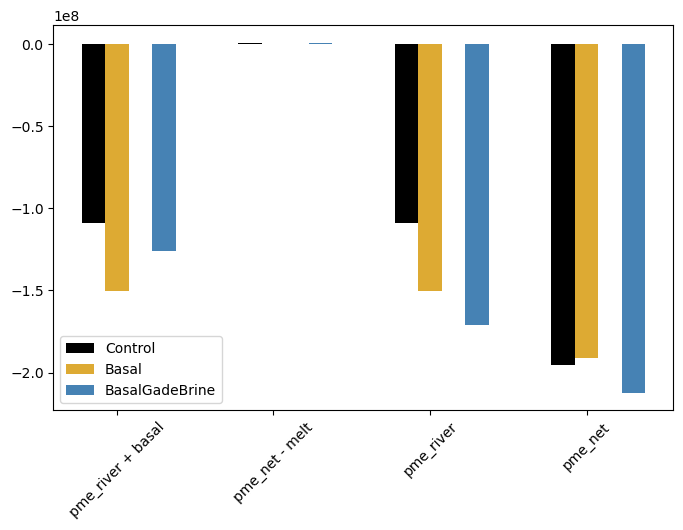

In [51]:
## SAME AS ABOVE BUT NOW SUMING BRINE_BGB in ALL TERMS:

fig, ax  = plt.subplots(figsize = (8,5))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.15, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k', label='Control')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine')
# pyplot.bar(0.5,brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine brine')
plt.legend()

# test with pme_net - melt
pyplot.bar(0.85, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')

pyplot.bar(1.85, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k')#, label='Control')
pyplot.bar(2., pme_river_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')#, label='Basal')
pyplot.bar(2.3, pme_river_annual_hint_shelf_BGB+brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')#, label='BasalGadeBrine')

# test with pme_net - melt
pyplot.bar(2.85, pme_net_annual_hint_shelf_ctrl , width=0.15, color='k')
pyplot.bar(3., pme_net_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')
pyplot.bar(3.3, pme_net_annual_hint_shelf_BGB +brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')

ax.set_xticks(np.arange(0,4),('pme_river + basal','pme_net - melt','pme_river','pme_net'),rotation=45)

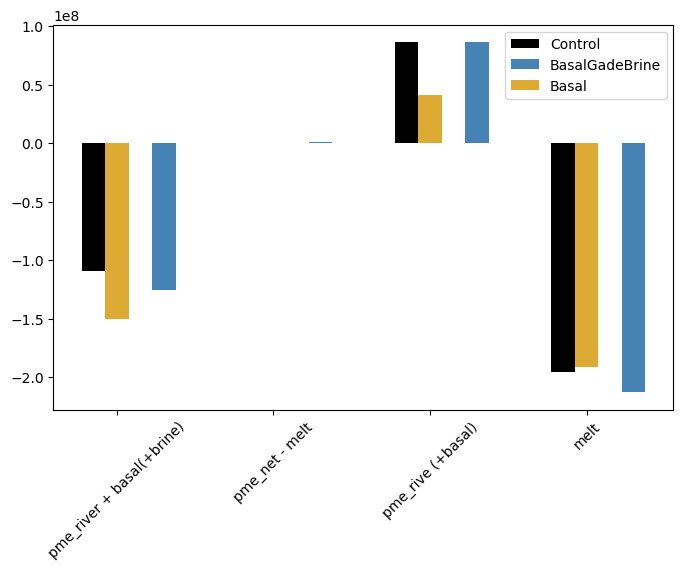

In [52]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (8,5))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.15, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k', label='Control')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33', label='Basal')
plt.legend()

# test with pme_net - melt
pyplot.bar(0.85, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

pyplot.bar(1.85, river_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(2.3, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

# pme_net includes melt!
pyplot.bar(2.85, melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(3.3, melt_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(3., melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

ax.set_xticks(np.arange(0,4),('pme_river + basal(+brine)','pme_net - melt','pme_rive (+basal)','melt'),rotation=45)

### Plotting timeseries:

In [68]:
%%time

### -- all expts, timeseries (should take a long time):

pme_net_hint_shelf_ctrl = var_hint_shelf(pme_net_ctrl.to_dataarray().squeeze())
pme_river_hint_shelf_ctrl = var_hint_shelf(pme_river_ctrl.to_dataarray().squeeze())
river_hint_shelf_ctrl = var_hint_shelf(river_ctrl.to_dataarray().squeeze());
wfiform_hint_shelf_ctrl = var_hint_shelf(wfiform_ctrl.to_dataarray().squeeze())
wfimelt_hint_shelf_ctrl = var_hint_shelf(wfimelt_ctrl.to_dataarray().squeeze())
FW_restore_hint_shelf_ctrl = var_hint_shelf(FW_restore_ctrl)
FW_ice_hint_shelf_ctrl = var_hint_shelf(FW_ice_ctrl)

# pme_net_hint_shelf_BG = var_hint_shelf(pme_net_BG.to_dataarray().squeeze())
# pme_river_hint_shelf_BG = var_hint_shelf(pme_river_BG.to_dataarray().squeeze())
# river_hint_shelf_BG = var_hint_shelf(river_BG.to_dataarray().squeeze())
# wfimelt_hint_shelf_BG = var_hint_shelf(wfimelt_BG.to_dataarray().squeeze())
# wfiform_hint_shelf_BG = var_hint_shelf(wfiform_BG.to_dataarray().squeeze())
# FW_restore_hint_shelf_BG = var_hint_shelf(FW_restore_BG)
# FW_ice_hint_shelf_BG = var_hint_shelf(FW_ice_BG)
# basal_hint_shelf_BG = var_hint_shelf(basal2d_BG.to_dataarray().squeeze())

pme_net_hint_shelf_noBG = var_hint_shelf(pme_net_noBG.to_dataarray().squeeze())
pme_river_hint_shelf_noBG = var_hint_shelf(pme_river_noBG.to_dataarray().squeeze())
river_hint_shelf_noBG = var_hint_shelf(river_noBG.to_dataarray().squeeze())
wfimelt_hint_shelf_noBG = var_hint_shelf(wfimelt_noBG.to_dataarray().squeeze())
wfiform_hint_shelf_noBG = var_hint_shelf(wfiform_noBG.to_dataarray().squeeze())
FW_restore_hint_shelf_noBG = var_hint_shelf(FW_restore_noBG)
FW_ice_hint_shelf_noBG = var_hint_shelf(FW_ice_noBG)
basal_hint_shelf_noBG = var_hint_shelf(basal2d_noBG.to_dataarray().squeeze())

pme_net_hint_shelf_BGB = var_hint_shelf(pme_net_BGB.to_dataarray().squeeze())
pme_river_hint_shelf_BGB = var_hint_shelf(pme_river_BGB.to_dataarray().squeeze())
river_hint_shelf_BGB = var_hint_shelf(river_BGB.to_dataarray().squeeze())
wfimelt_hint_shelf_BGB = var_hint_shelf(wfimelt_BGB.to_dataarray().squeeze())
wfiform_hint_shelf_BGB = var_hint_shelf(wfiform_BGB.to_dataarray().squeeze())
FW_restore_hint_shelf_BGB = var_hint_shelf(FW_restore_BGB)
FW_ice_hint_shelf_BGB = var_hint_shelf(FW_ice_BGB)
basal_hint_shelf_BGB = var_hint_shelf(basal2d_BGB.to_dataarray().squeeze())

(24, 483, 3600)
(24, 483, 3600)
(24, 483, 3600)
Unexpected exception formatting exception. Falling back to standard exception


2025-06-26 13:56:42,779 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/g/d

In [ ]:
%%time

### Repeat fs, timeseries (should take a long time):

pme_net_hint_shelf_ctrl_s = var_hint_shelf(pme_net_ctrl.to_dataarray().squeeze())
pme_river_hint_shelf_ctrl_s = var_hint_shelf(pme_river_ctrl.to_dataarray().squeeze())
river_hint_shelf_ctrl_s = var_hint_shelf(river_ctrl.to_dataarray().squeeze());
wfiform_hint_shelf_ctrl_s = var_hint_shelf(wfiform_ctrl.to_dataarray().squeeze())
wfimelt_hint_shelf_ctrl_s = var_hint_shelf(wfimelt_ctrl.to_dataarray().squeeze())
FW_restore_hint_shelf_ctrl_s = var_hint_shelf(FW_restore_ctrl)
FW_ice_hint_shelf_ctrl_s = var_hint_shelf(FW_ice_ctrl)

# pme_net_hint_shelf_BG_s = var_hint_shelf(pme_net_BG.to_dataarray().squeeze())
# pme_river_hint_shelf_BG_s = var_hint_shelf(pme_river_BG.to_dataarray().squeeze())
# river_hint_shelf_BG_s = var_hint_shelf(river_BG.to_dataarray().squeeze())
# wfimelt_hint_shelf_BG_s = var_hint_shelf(wfimelt_BG.to_dataarray().squeeze())
# wfiform_hint_shelf_BG_s = var_hint_shelf(wfiform_BG.to_dataarray().squeeze())
# FW_restore_hint_shelf_BG_s = var_hint_shelf(FW_restore_BG)
# FW_ice_hint_shelf_BG_s = var_hint_shelf(FW_ice_BG)
# basal_hint_shelf_BG_s = var_hint_shelf(basal2d_BG.to_dataarray().squeeze())

pme_net_hint_shelf_noBG_s = var_hint_shelf(pme_net_noBG.to_dataarray().squeeze())
pme_river_hint_shelf_noBG_s = var_hint_shelf(pme_river_noBG.to_dataarray().squeeze())
river_hint_shelf_noBG_s = var_hint_shelf(river_noBG.to_dataarray().squeeze())
wfimelt_hint_shelf_noBG_s = var_hint_shelf(wfimelt_noBG.to_dataarray().squeeze())
wfiform_hint_shelf_noBG_s = var_hint_shelf(wfiform_noBG.to_dataarray().squeeze())
FW_restore_hint_shelf_noBG_s = var_hint_shelf(FW_restore_noBG)
FW_ice_hint_shelf_noBG_s = var_hint_shelf(FW_ice_noBG)
basal_hint_shelf_noBG_s = var_hint_shelf(basal2d_noBG.to_dataarray().squeeze())

pme_net_hint_shelf_BGB_s = var_hint_shelf(pme_net_BGB.to_dataarray().squeeze())
pme_river_hint_shelf_BGB_s = var_hint_shelf(pme_river_BGB.to_dataarray().squeeze())
river_hint_shelf_BGB_s = var_hint_shelf(river_BGB.to_dataarray().squeeze())
wfimelt_hint_shelf_BGB_s = var_hint_shelf(wfimelt_BGB.to_dataarray().squeeze())
wfiform_hint_shelf_BGB_s = var_hint_shelf(wfiform_BGB.to_dataarray().squeeze())
FW_restore_hint_shelf_BGB_s = var_hint_shelf(FW_restore_BGB)
FW_ice_hint_shelf_BGB_s = var_hint_shelf(FW_ice_BGB)
basal_hint_shelf_BGB_s = var_hint_shelf(basal2d_BGB.to_dataarray().squeeze())

2025-06-26 13:56:42,798 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/g/d

(24, 483, 3600)


2025-06-26 13:56:44,806 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/asyncio/base_events.py", line 650, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/asyncio/locks.py", l

In [47]:
%%time

brine_hint_shelf_BGB_s = var_hint_shelf(brine_BGB.to_dataarray().squeeze())

melt_ctrl_s = wfiform_ctrl.to_dataarray().squeeze() + wfimelt_ctrl.to_dataarray().squeeze()
melt_hint_shelf_ctrl_s = var_hint_shelf(melt_ctrl)

melt_noBG = wfiform_noBG.to_dataarray().squeeze() + wfimelt_noBG.to_dataarray().squeeze()
melt_hint_shelf_noBG = var_hint_shelf(melt_noBG)

melt_BG_s = wfiform_BG.to_dataarray().squeeze() + wfimelt_BG.to_dataarray().squeeze()
melt_hint_shelf_BG_s = var_hint_shelf(melt_BG)

melt_BGB_s = wfiform_BGB.to_dataarray().squeeze() + wfimelt_BGB.to_dataarray().squeeze()
melt_hint_shelf_BGB_s = var_hint_shelf(melt_BGB)

(121, 483, 3600)
(132, 483, 3600)
(120, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
CPU times: user 2min 10s, sys: 16.8 s, total: 2min 26s
Wall time: 7min 29s


(-600000000.0, 600000000.0)

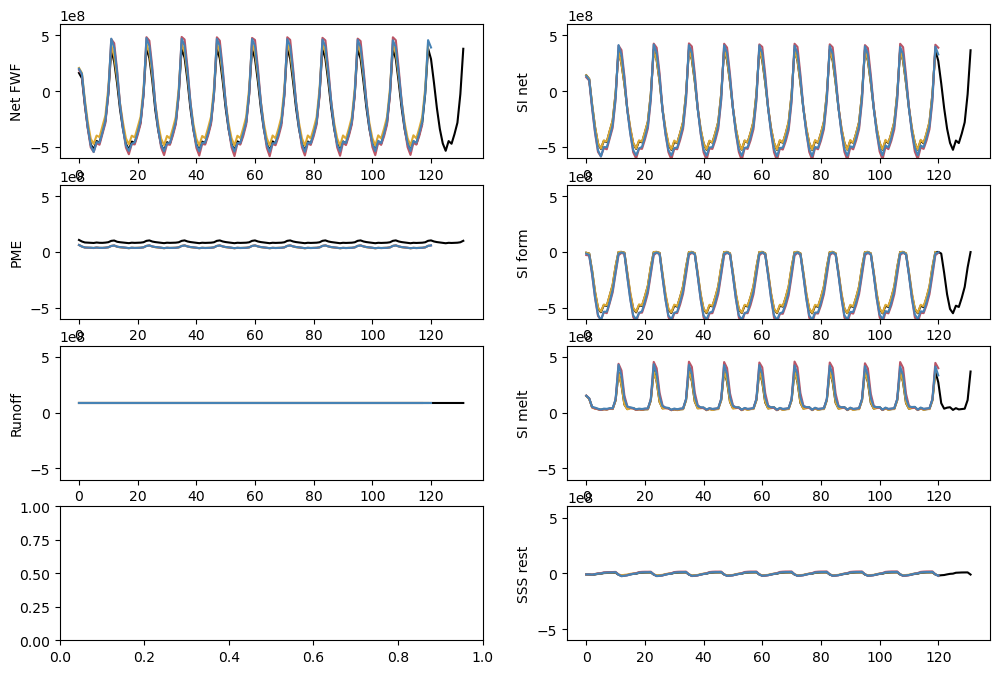

In [49]:
## test plotting timeseries:

fig, ax  = plt.subplots(nrows=4,ncols=2, figsize = (12,8))
ax[0,0].plot(pme_net_hint_shelf_ctrl,label='ctrl',color='k')
ax[0,0].plot(pme_net_hint_shelf_noBG + basal_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[0,0].plot(pme_net_hint_shelf_BG[0:118] + basal_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[0,0].plot(pme_net_hint_shelf_BGB + basal_hint_shelf_BGB + brine_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[0,0].set_ylabel('Net FWF')
# ax[0].title('Net FWF',loc='outside')
ax[0,0].set_ylim(-6e8,+6e8)

# ax[1,0].plot((pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl),label='ctrl',color='k')
ax[1,0].plot(pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl,label='ctrl',color='k')
ax[1,0].plot(pme_river_hint_shelf_noBG - melt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[1,0].plot(pme_river_hint_shelf_BG - melt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[1,0].plot(pme_river_hint_shelf_BGB - melt_hint_shelf_BGB + brine_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[1,0].set_ylabel('PME')
ax[1,0].set_ylim(-6e8,+6e8)

ax[2,0].plot(river_hint_shelf_ctrl,label='ctrl',color='k')
ax[2,0].plot(river_hint_shelf_noBG + basal_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[2,0].plot(river_hint_shelf_BG[0:118] + basal_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[2,0].plot(river_hint_shelf_BGB + basal_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[2,0].set_ylabel('Runoff')
ax[2,0].set_ylim(-6e8,+6e8)

ax[0,1].plot(melt_hint_shelf_ctrl,label='ctrl',color='k')
ax[0,1].plot(melt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[0,1].plot(melt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[0,1].plot(melt_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[0,1].set_ylabel('SI net')
ax[0,1].set_ylim(-6e8,+6e8)

ax[1,1].plot(wfiform_hint_shelf_ctrl,label='ctrl',color='k')
ax[1,1].plot(wfiform_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[1,1].plot(wfiform_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[1,1].plot(wfiform_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[1,1].set_ylabel('SI form')
ax[1,1].set_ylim(-6e8,+6e8)

ax[2,1].plot(wfimelt_hint_shelf_ctrl,label='ctrl',color='k')
ax[2,1].plot(wfimelt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[2,1].plot(wfimelt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[2,1].plot(wfimelt_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[2,1].set_ylabel('SI melt')
ax[2,1].set_ylim(-6e8,+6e8)

ax[3,1].plot(FW_restore_hint_shelf_ctrl,label='ctrl',color='k')
ax[3,1].plot(FW_restore_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[3,1].plot(FW_restore_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[3,1].plot(FW_restore_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[3,1].set_ylabel('SSS rest')
ax[3,1].set_ylim(-6e8,+6e8)






Text(0, 0.5, 'PME')

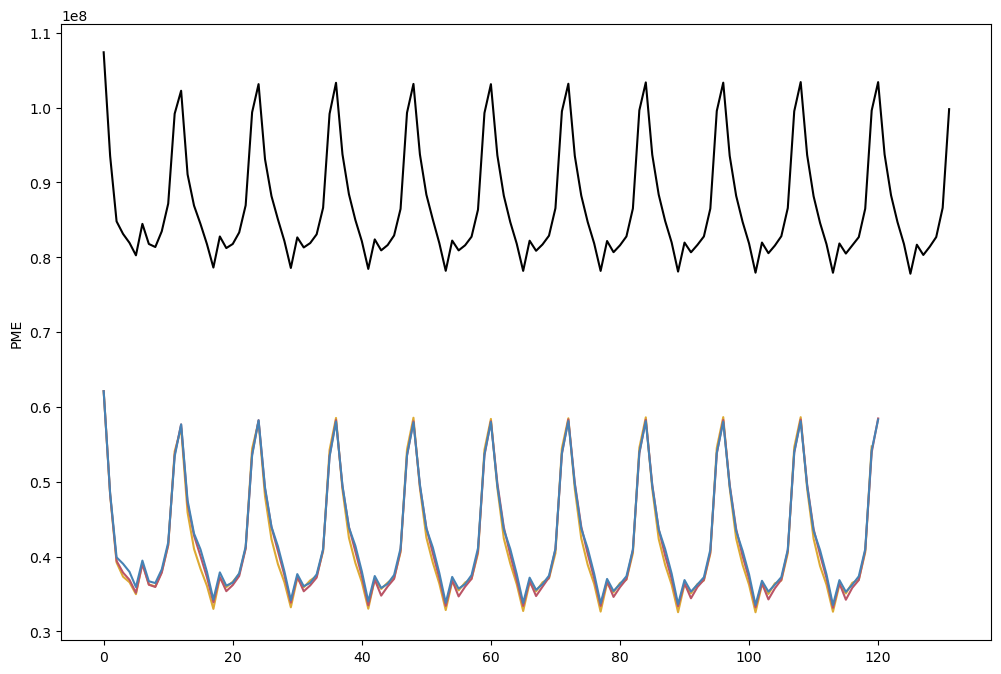

In [41]:
fig, ax  = plt.subplots(nrows=1,ncols=1, figsize = (12,8))

# ax.plot((pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl)*0.5,label='ctrl',color='k')
ax.plot(pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl,label='ctrl',color='k')
ax.plot(pme_river_hint_shelf_noBG - melt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax.plot(pme_river_hint_shelf_BG - melt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax.plot(pme_river_hint_shelf_BGB - melt_hint_shelf_BGB + brine_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax.set_ylabel('PME')

#### Some map plots below:

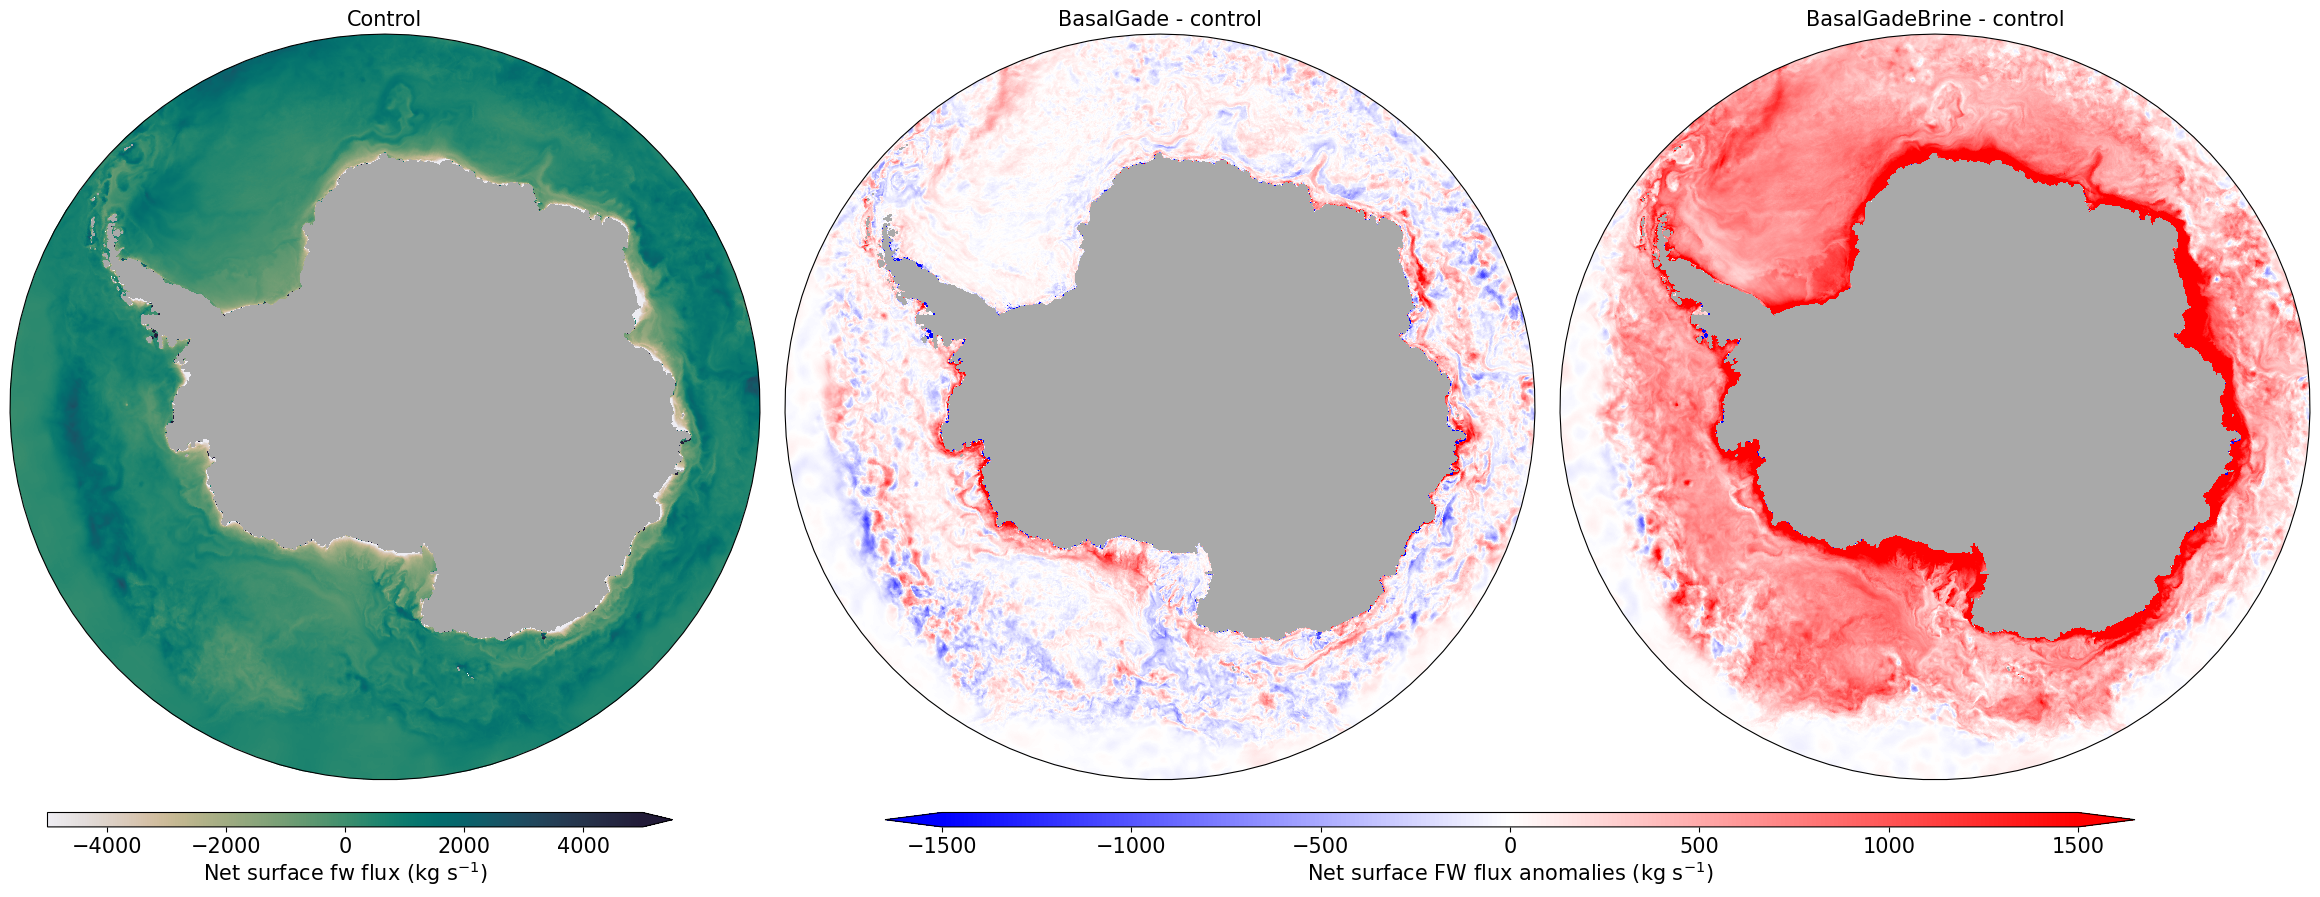

In [32]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(pme_river.xt_ocean, pme_river.yt_ocean, pme_river.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(pme_river_BG.xt_ocean, pme_river_BG.yt_ocean, pme_river_BG.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(pme_river_BGB.xt_ocean, pme_river_BGB.yt_ocean, (pme_river_BGB.mean('time')*area_t + brine_BGB.mean('time')) - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Net surface fw flux (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Net surface FW flux anomalies (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'pme_river_BG_BGB_anom_y'+str(year)+'.png')

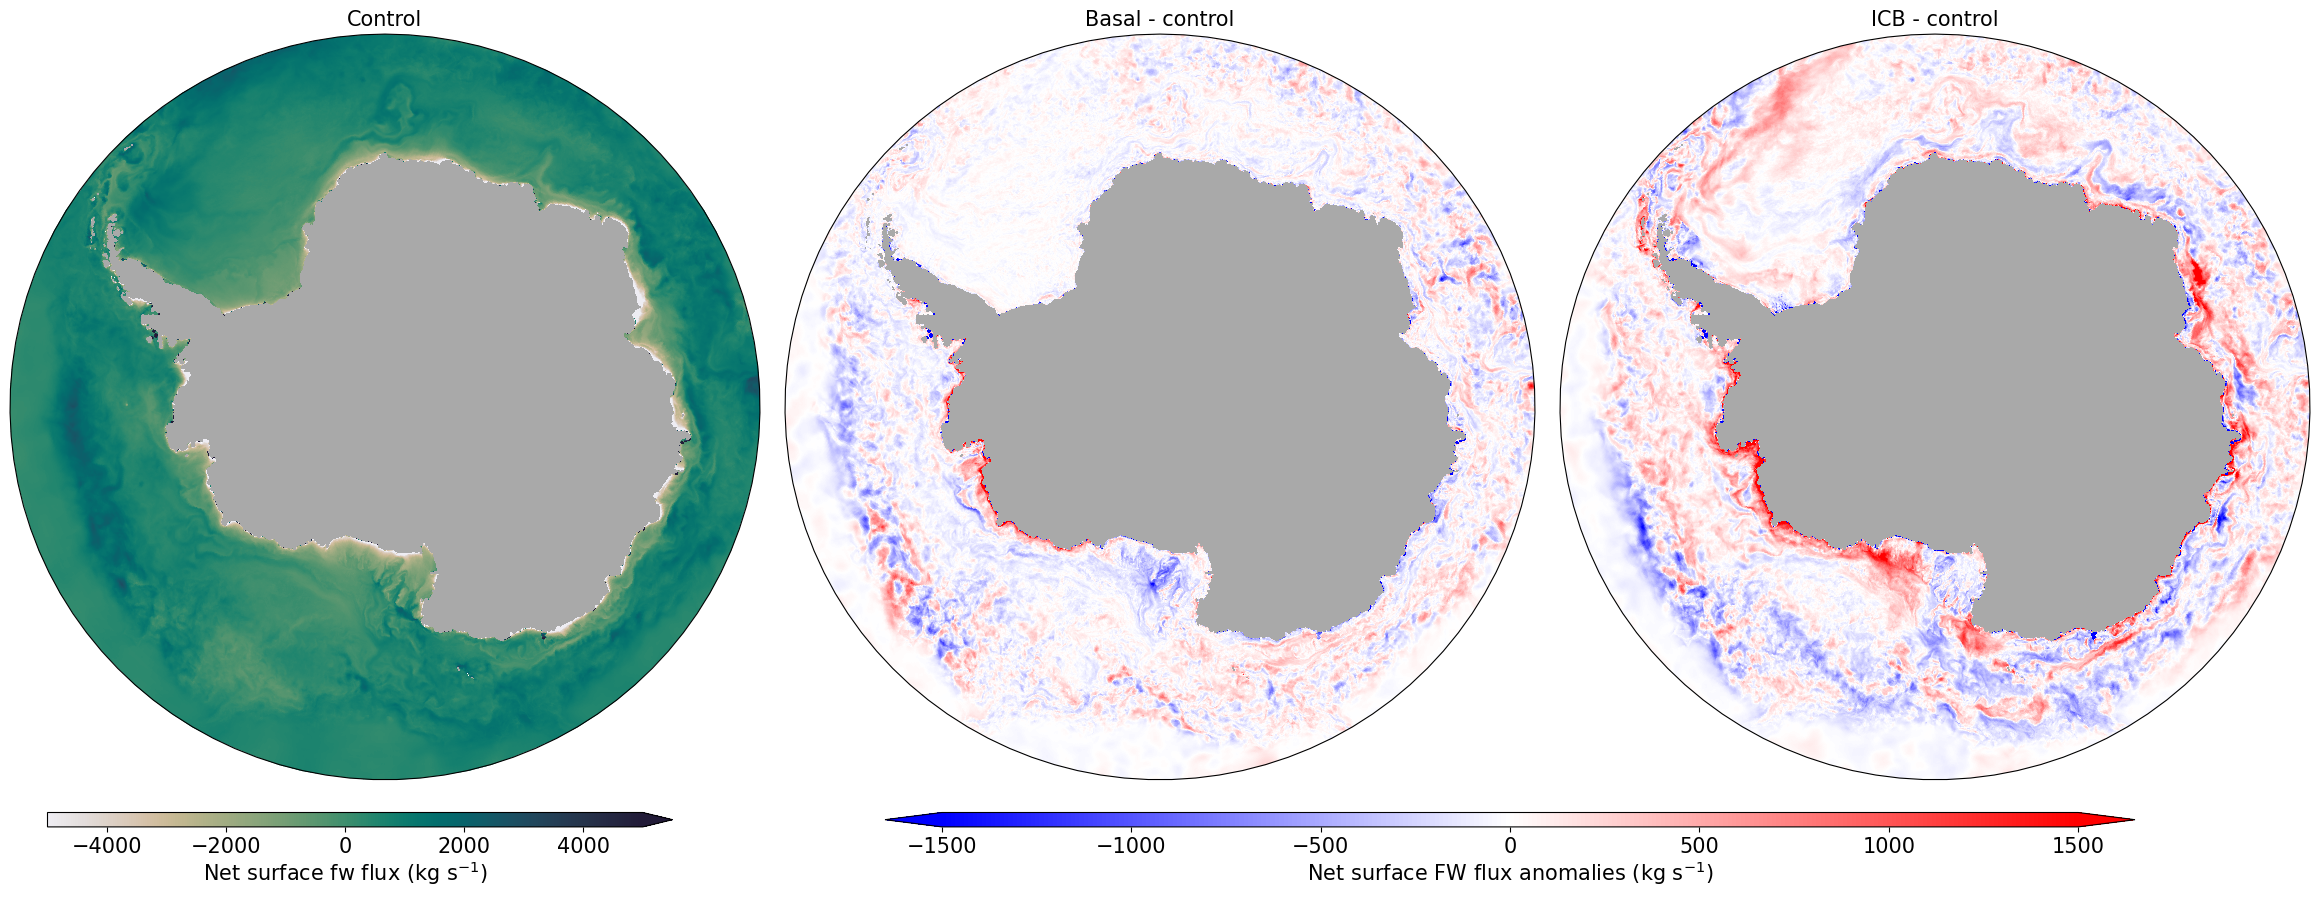

In [33]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(pme_river.xt_ocean, pme_river.yt_ocean, pme_river.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(pme_river_noBG.xt_ocean, pme_river_noBG.yt_ocean, pme_river_noBG.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(pme_river_ICB.xt_ocean, pme_river_ICB.yt_ocean, pme_river_ICB.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Net surface fw flux (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Net surface FW flux anomalies (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'pme_river_noBG_ICB_anom_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(melt.xt_ocean, melt.yt_ocean, melt.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(melt_BG.xt_ocean, melt_BG.yt_ocean, melt_BG.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(melt_BGB.xt_ocean, melt_BGB.yt_ocean, melt_BGB.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea ice(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea ice (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'melt_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(melt.xt_ocean, melt.yt_ocean, melt.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(melt_noBG.xt_ocean, melt_noBG.yt_ocean, melt_noBG.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(melt_ICB.xt_ocean, melt_ICB.yt_ocean, melt_ICB.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea ice(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea ice (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'melt_anom_noBG_ICB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_ice.xt_ocean, FW_ice.yt_ocean, FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_ice_BG.xt_ocean, FW_ice_BG.yt_ocean, FW_ice_BG.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_ice_BGB.xt_ocean, FW_ice_ICB.yt_ocean, FW_ice_ICB.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea-ice formation(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea-ice formation (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)


### Save fig
plt.savefig(figdir+'FW_ice_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_ice.xt_ocean, FW_ice.yt_ocean, FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_ice_noBG.xt_ocean, FW_ice_noBG.yt_ocean, FW_ice_noBG.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_ice_ICB.xt_ocean, FW_ice_ICB.yt_ocean, FW_ice_ICB.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea-ice formation(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea-ice formation (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)


### Save fig
plt.savefig(figdir+'FW_ice_anom_noBG_ICBB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_restore.xt_ocean, FW_restore.yt_ocean, FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_restore_BG.xt_ocean, FW_restore_BG.yt_ocean, FW_restore_BG.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sina(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_restore_BGB.xt_ocean, FW_restore_BGB.yt_ocean, FW_restore_BGB.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'FW_restore_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_restore.xt_ocean, FW_restore.yt_ocean, FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_restore_noBG.xt_ocean, FW_restore_noBG.yt_ocean, FW_restore_noBG.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sina(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_restore_ICB.xt_ocean, FW_restore_ICB.yt_ocean, FW_restore_ICB.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'FW_restore_anom_noBG_ICB_y'+str(year)+'.png')